# Linear Regression

Features: `EarningsYield_zscore`, `AssetGrowth_zscore`, `Accruals_zscore`, `Momentum12_1_zscore`  
Target: `target_forward_return_21d_zscore`  
Validation: expanding-window walk-forward (train on all dates before T, predict on T).  
Minimum training periods before first prediction: `MIN_TRAIN_PERIODS`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

# ── config ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/baseline/model_dataset.parquet"
FEATURES = [
    "EarningsYield_zscore",
    "AssetGrowth_zscore",
    "Accruals_zscore",
    "Momentum12_1_zscore",
]
TARGET = "target_forward_return_21d_zscore"
MIN_TRAIN_PERIODS = 12  # number of full cross-sections required before first prediction
# ─────────────────────────────────────────────────────────────────────────────

## Load & inspect

In [7]:
df = pd.read_parquet(DATA_PATH)
# df = df.dropna(subset=FEATURES + [TARGET])
df = df.sort_values("signal_date").reset_index(drop=True)

dates = df["signal_date"].sort_values().unique()
print(
    f"{len(dates)} cross-section dates | {df['ticker'].nunique()} tickers | {len(df):,} rows"
)
df.head(3)

95 cross-section dates | 494 tickers | 45,201 rows


,ticker,signal_date,EarningsYield_zscore,AssetGrowth_zscore,Accruals_zscore,Momentum12_1_zscore,target_forward_return_21d_zscore
0,A,2015-01-30,-0.307394,-0.513103,0.094947,-1.089900,0.792406
1,NWSA,2015-01-30,2.628299,-0.242187,0.039993,-1.160230,1.291230
2,NWS,2015-01-30,2.747612,-0.242187,0.039993,-1.241683,1.319400


## Walk-forward validation

In [8]:
records = []  # one row per test cross-section

model = LinearRegression()

for i, test_date in enumerate(dates):
    if i < MIN_TRAIN_PERIODS:
        continue  # need at least MIN_TRAIN_PERIODS periods of history

    train_mask = df["signal_date"] < test_date
    test_mask = df["signal_date"] == test_date

    X_train = df.loc[train_mask, FEATURES].values
    y_train = df.loc[train_mask, TARGET].values
    X_test = df.loc[test_mask, FEATURES].values
    y_test = df.loc[test_mask, TARGET].values

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ic, _ = spearmanr(y_pred, y_test)  # rank IC (information coefficient)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

    records.append(
        {
            "date": test_date,
            "n_train": int(train_mask.sum()),
            "n_test": int(test_mask.sum()),
            "IC": ic,
            "RMSE": rmse,
            "coef_EY": model.coef_[0],
            "coef_AG": model.coef_[1],
            "coef_Acc": model.coef_[2],
            "coef_Mom": model.coef_[3],
        }
    )

results = pd.DataFrame(records).set_index("date")
print(f"Walk-forward results: {len(results)} test periods")
results.head()

Walk-forward results: 83 test periods


,n_train,n_test,IC,RMSE,coef_EY,coef_AG,coef_Acc,coef_Mom
date,,,,,,,,
2016-01-29,5500,461,-0.219651,1.021471,-0.010919,0.001461,0.037071,0.076257
2016-02-29,5961,461,-0.175691,1.011403,-0.003589,0.007495,0.036745,0.051479
2016-03-31,6422,462,-0.190420,1.011459,-0.004096,0.006819,0.033161,0.034519
2016-04-29,6884,462,0.030171,0.999531,-0.004281,0.009623,0.031785,0.010273
2016-05-31,7346,462,0.127531,0.996651,-0.004605,0.010106,0.027815,0.013029


## Summary statistics

In [9]:
ic = results["IC"]
mean_ic = ic.mean()
icir = mean_ic / ic.std()  # IC information ratio

print(f"Mean IC   : {mean_ic:.4f}")
print(f"IC StdDev : {ic.std():.4f}")
print(f"ICIR      : {icir:.4f}  (mean / std)")
print(f"IC > 0    : {(ic > 0).mean():.1%} of periods")
print(f"IC > 0.05 : {(ic > 0.05).mean():.1%} of periods")
print()
print(f"Mean RMSE : {results['RMSE'].mean():.4f}")

coef_cols = ["coef_EY", "coef_AG", "coef_Acc", "coef_Mom"]
print("\nMean coefficients:")
results[coef_cols].mean().rename(
    {
        "coef_EY": "EarningsYield",
        "coef_AG": "AssetGrowth",
        "coef_Acc": "Accruals",
        "coef_Mom": "Momentum12_1",
    }
)

Mean IC   : -0.0312
IC StdDev : 0.1156
ICIR      : -0.2703  (mean / std)
IC > 0    : 41.0% of periods
IC > 0.05 : 25.3% of periods

Mean RMSE : 1.0003

Mean coefficients:


EarningsYield    0.003672
AssetGrowth      0.010982
Accruals         0.003050
Momentum12_1    -0.000595
dtype: float64

## Plots

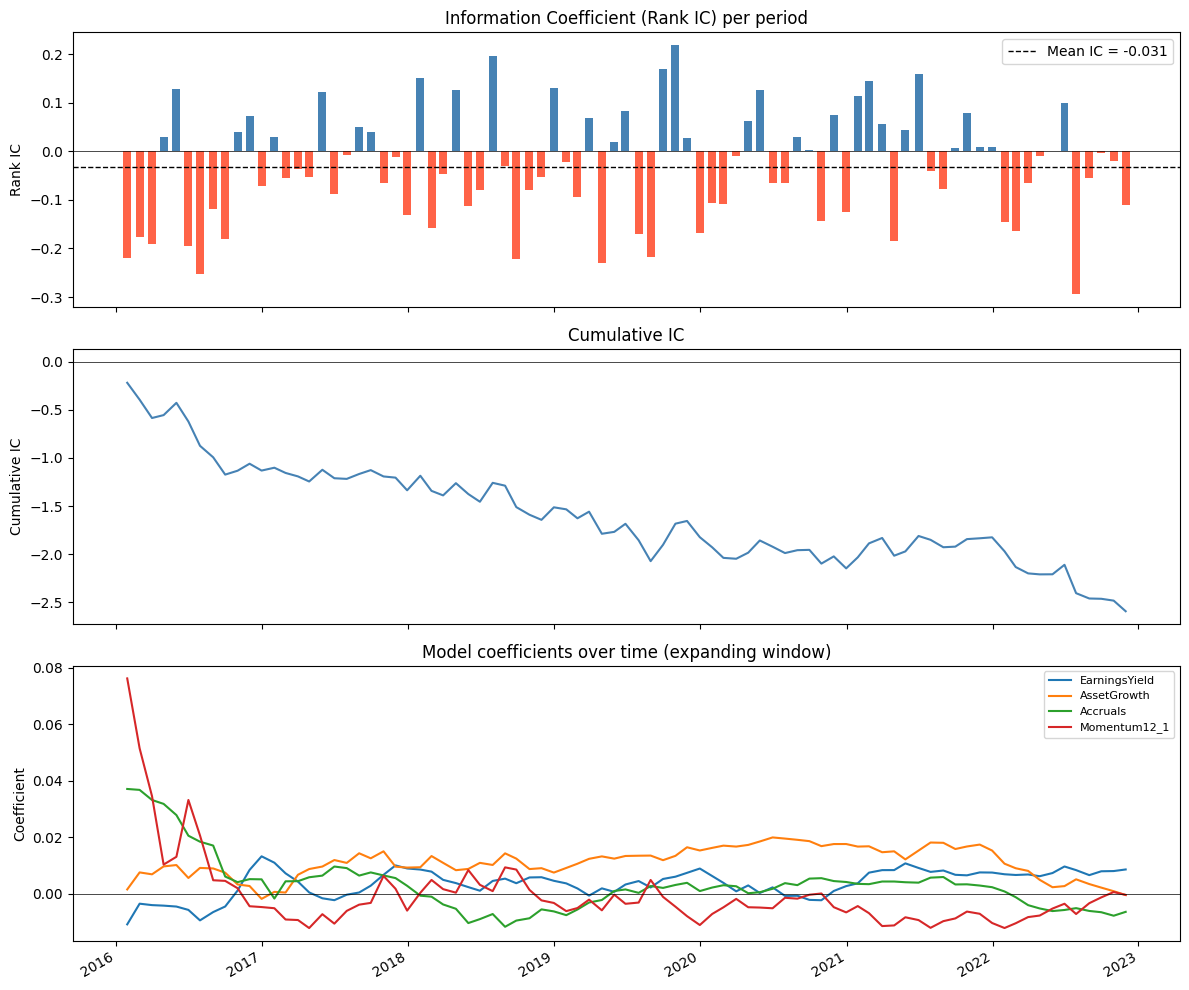

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ── IC over time ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(
    results.index,
    results["IC"],
    width=20,
    color=np.where(results["IC"] >= 0, "steelblue", "tomato"),
)
ax.axhline(
    mean_ic,
    color="black",
    linewidth=1,
    linestyle="--",
    label=f"Mean IC = {mean_ic:.3f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Rank IC")
ax.set_title("Information Coefficient (Rank IC) per period")
ax.legend()

# ── Cumulative IC ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(results.index, results["IC"].cumsum(), color="steelblue")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative IC")

# ── Rolling coefficients ──────────────────────────────────────────────────────
ax = axes[2]
label_map = {
    "coef_EY": "EarningsYield",
    "coef_AG": "AssetGrowth",
    "coef_Acc": "Accruals",
    "coef_Mom": "Momentum12_1",
}
for col, label in label_map.items():
    ax.plot(results.index, results[col], label=label)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Coefficient")
ax.set_title("Model coefficients over time (expanding window)")
ax.legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---

## IC-Weighted Linear Ensemble

Each feature is fit as a **univariate** OLS predictor independently. The four predictions are combined with weights proportional to each feature's mean IC over the trailing `IC_WEIGHT_WINDOW` periods. Features with negative recent IC get weight 0. If all weights are 0, falls back to equal weighting.

In [11]:
IC_WEIGHT_WINDOW = 12  # trailing periods used to compute per-feature IC weights

ic_history = {f: [] for f in FEATURES}  # rolling per-feature IC, built up as we go
ensemble_records = []

for i, test_date in enumerate(dates):
    if i < MIN_TRAIN_PERIODS:
        continue

    train_mask = df["signal_date"] < test_date
    test_mask = df["signal_date"] == test_date

    y_train = df.loc[train_mask, TARGET].values
    y_test = df.loc[test_mask, TARGET].values

    # ── univariate predictions + current-period IC per feature ───────────────
    preds_by_feature = {}
    current_ics = {}
    for feat in FEATURES:
        X_tr = df.loc[train_mask, [feat]].values
        X_te = df.loc[test_mask, [feat]].values
        pred_f = LinearRegression().fit(X_tr, y_train).predict(X_te)
        ic_f, _ = spearmanr(pred_f, y_test)
        preds_by_feature[feat] = pred_f
        current_ics[feat] = ic_f

    # ── weights from *prior* IC history (no lookahead) ───────────────────────
    weights = {}
    for feat in FEATURES:
        recent = ic_history[feat][-IC_WEIGHT_WINDOW:]
        weights[feat] = max(0.0, np.mean(recent)) if recent else 0.0

    total_w = sum(weights.values())
    if total_w == 0:
        weights = {f: 1 / len(FEATURES) for f in FEATURES}  # equal fallback
    else:
        weights = {f: w / total_w for f, w in weights.items()}

    # ── ensemble prediction ───────────────────────────────────────────────────
    y_pred_ens = sum(weights[f] * preds_by_feature[f] for f in FEATURES)
    ic_ens, _ = spearmanr(y_pred_ens, y_test)
    rmse_ens = np.sqrt(np.mean((y_test - y_pred_ens) ** 2))

    ensemble_records.append(
        {
            "date": test_date,
            "IC": ic_ens,
            "RMSE": rmse_ens,
            **{f"w_{f}": weights[f] for f in FEATURES},
        }
    )

    # update IC history *after* using it (strict walk-forward)
    for feat in FEATURES:
        ic_history[feat].append(current_ics[feat])

ens = pd.DataFrame(ensemble_records).set_index("date")
print(f"Ensemble walk-forward results: {len(ens)} test periods")
ens.head()

Ensemble walk-forward results: 83 test periods


,IC,RMSE,w_EarningsYield_zscore,w_AssetGrowth_zscore,w_Accruals_zscore,w_Momentum12_1_zscore
date,,,,,,
2016-01-29,-0.229469,1.004220,0.25,0.250000,0.250000,0.25
2016-02-29,-0.049161,0.999514,0.00,0.541472,0.458528,0.00
2016-03-31,-0.010622,0.998890,0.00,1.000000,0.000000,0.00
2016-04-29,-0.023360,0.999562,0.00,0.399731,0.600269,0.00
2016-05-31,-0.059751,0.999267,0.00,0.908496,0.091504,0.00


### Ensemble summary statistics

In [12]:
ens_ic = ens["IC"]
mean_ens_ic = ens_ic.mean()
ens_icir = mean_ens_ic / ens_ic.std()

print("── Ensemble ──────────────────────────────")
print(f"Mean IC   : {mean_ens_ic:.4f}")
print(f"IC StdDev : {ens_ic.std():.4f}")
print(f"ICIR      : {ens_icir:.4f}")
print(f"IC > 0    : {(ens_ic > 0).mean():.1%} of periods")
print(f"IC > 0.05 : {(ens_ic > 0.05).mean():.1%} of periods")
print(f"Mean RMSE : {ens['RMSE'].mean():.4f}")
print()
print("── vs OLS baseline ───────────────────────")
print(f"Mean IC   : {mean_ic:.4f}")
print(f"ICIR      : {icir:.4f}")

── Ensemble ──────────────────────────────
Mean IC   : -0.0128
IC StdDev : 0.0949
ICIR      : -0.1348
IC > 0    : 42.2% of periods
IC > 0.05 : 25.3% of periods
Mean RMSE : 0.9992

── vs OLS baseline ───────────────────────
Mean IC   : -0.0312
ICIR      : -0.2703


### Ensemble plots

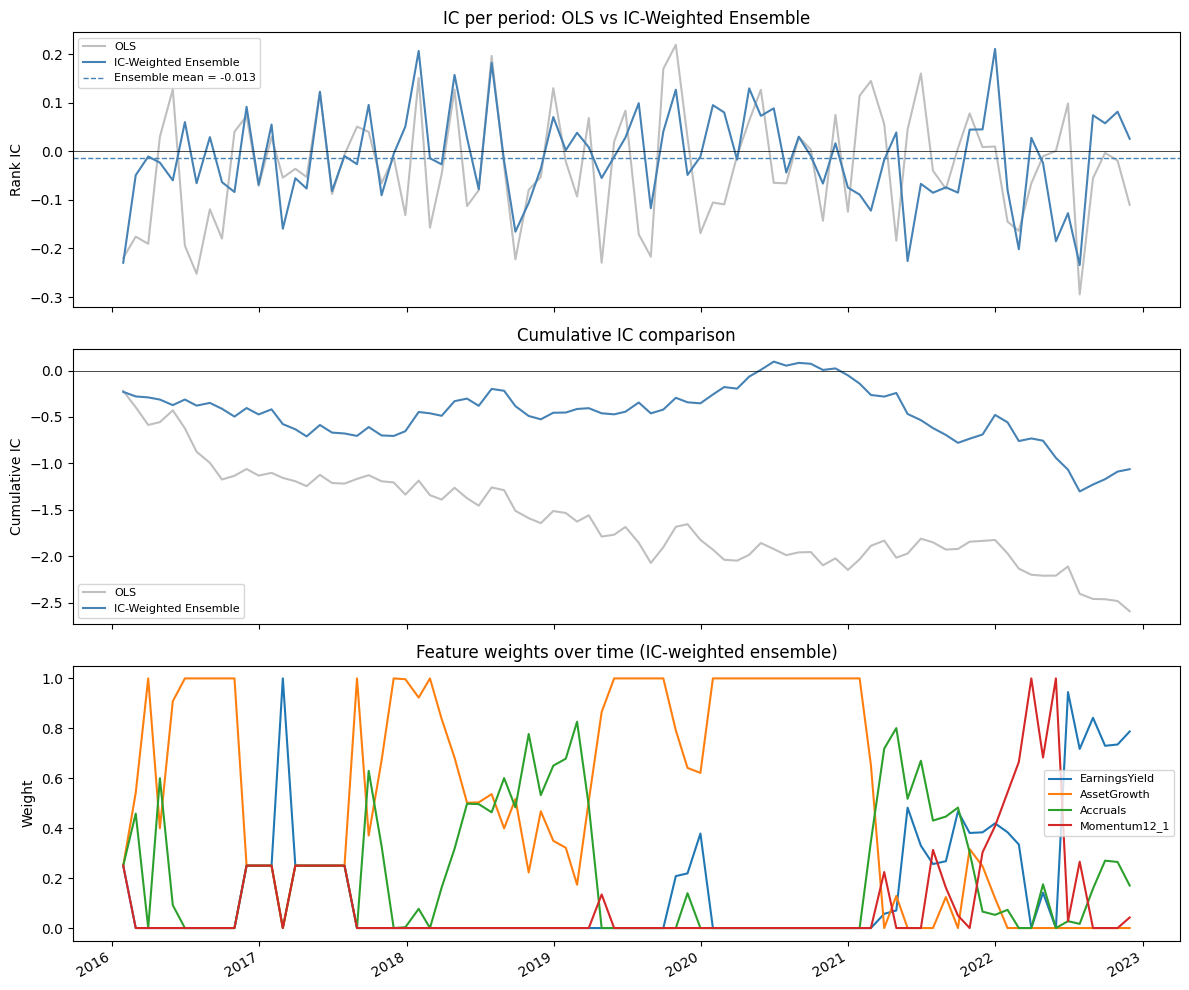

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ── IC per period: ensemble vs OLS ───────────────────────────────────────────
ax = axes[0]
ax.plot(results.index, results["IC"], color="gray", alpha=0.5, label="OLS")
ax.plot(ens.index, ens["IC"], color="steelblue", label="IC-Weighted Ensemble")
ax.axhline(
    mean_ens_ic,
    color="steelblue",
    linewidth=1,
    linestyle="--",
    label=f"Ensemble mean = {mean_ens_ic:.3f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Rank IC")
ax.set_title("IC per period: OLS vs IC-Weighted Ensemble")
ax.legend(fontsize=8)

# ── Cumulative IC comparison ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(results.index, results["IC"].cumsum(), color="gray", alpha=0.5, label="OLS")
ax.plot(ens.index, ens["IC"].cumsum(), color="steelblue", label="IC-Weighted Ensemble")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative IC comparison")
ax.legend(fontsize=8)

# ── Feature weights over time ─────────────────────────────────────────────────
ax = axes[2]
weight_cols = [f"w_{f}" for f in FEATURES]
label_map = dict(
    zip(weight_cols, ["EarningsYield", "AssetGrowth", "Accruals", "Momentum12_1"])
)
for col, label in label_map.items():
    ax.plot(ens.index, ens[col], label=label)
ax.set_ylabel("Weight")
ax.set_title("Feature weights over time (IC-weighted ensemble)")
ax.legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()